# YOLO Fine-Tuning

300 manually labeled frames from Budućnost–Sutjeska (full 90 min).  
Classes: `player` (0), `ball` (1), `goalkeeper` (2), `referee` (3)

In [1]:
import sys
import importlib
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import src.dataset
importlib.reload(src.dataset)

from src.config import Config
from src.dataset import create_data_yaml, split_val, visualize_labels

dataset_dir = Config.PROJECT_ROOT / "dataset"
train_imgs = len(list((dataset_dir / "images" / "train").glob("*.jpg")))
val_imgs = len(list((dataset_dir / "images" / "val").glob("*.jpg"))) if (dataset_dir / "images" / "val").exists() else 0
print(f"Dataset: {dataset_dir}")
print(f"  Total: {train_imgs + val_imgs} frames ({train_imgs} train, {val_imgs} val)")

Dataset: C:\Users\pavle\OneDrive\Desktop\my github\football-computer-vision\football-computer-vision\dataset
  Total: 300 frames (192 train, 108 val)


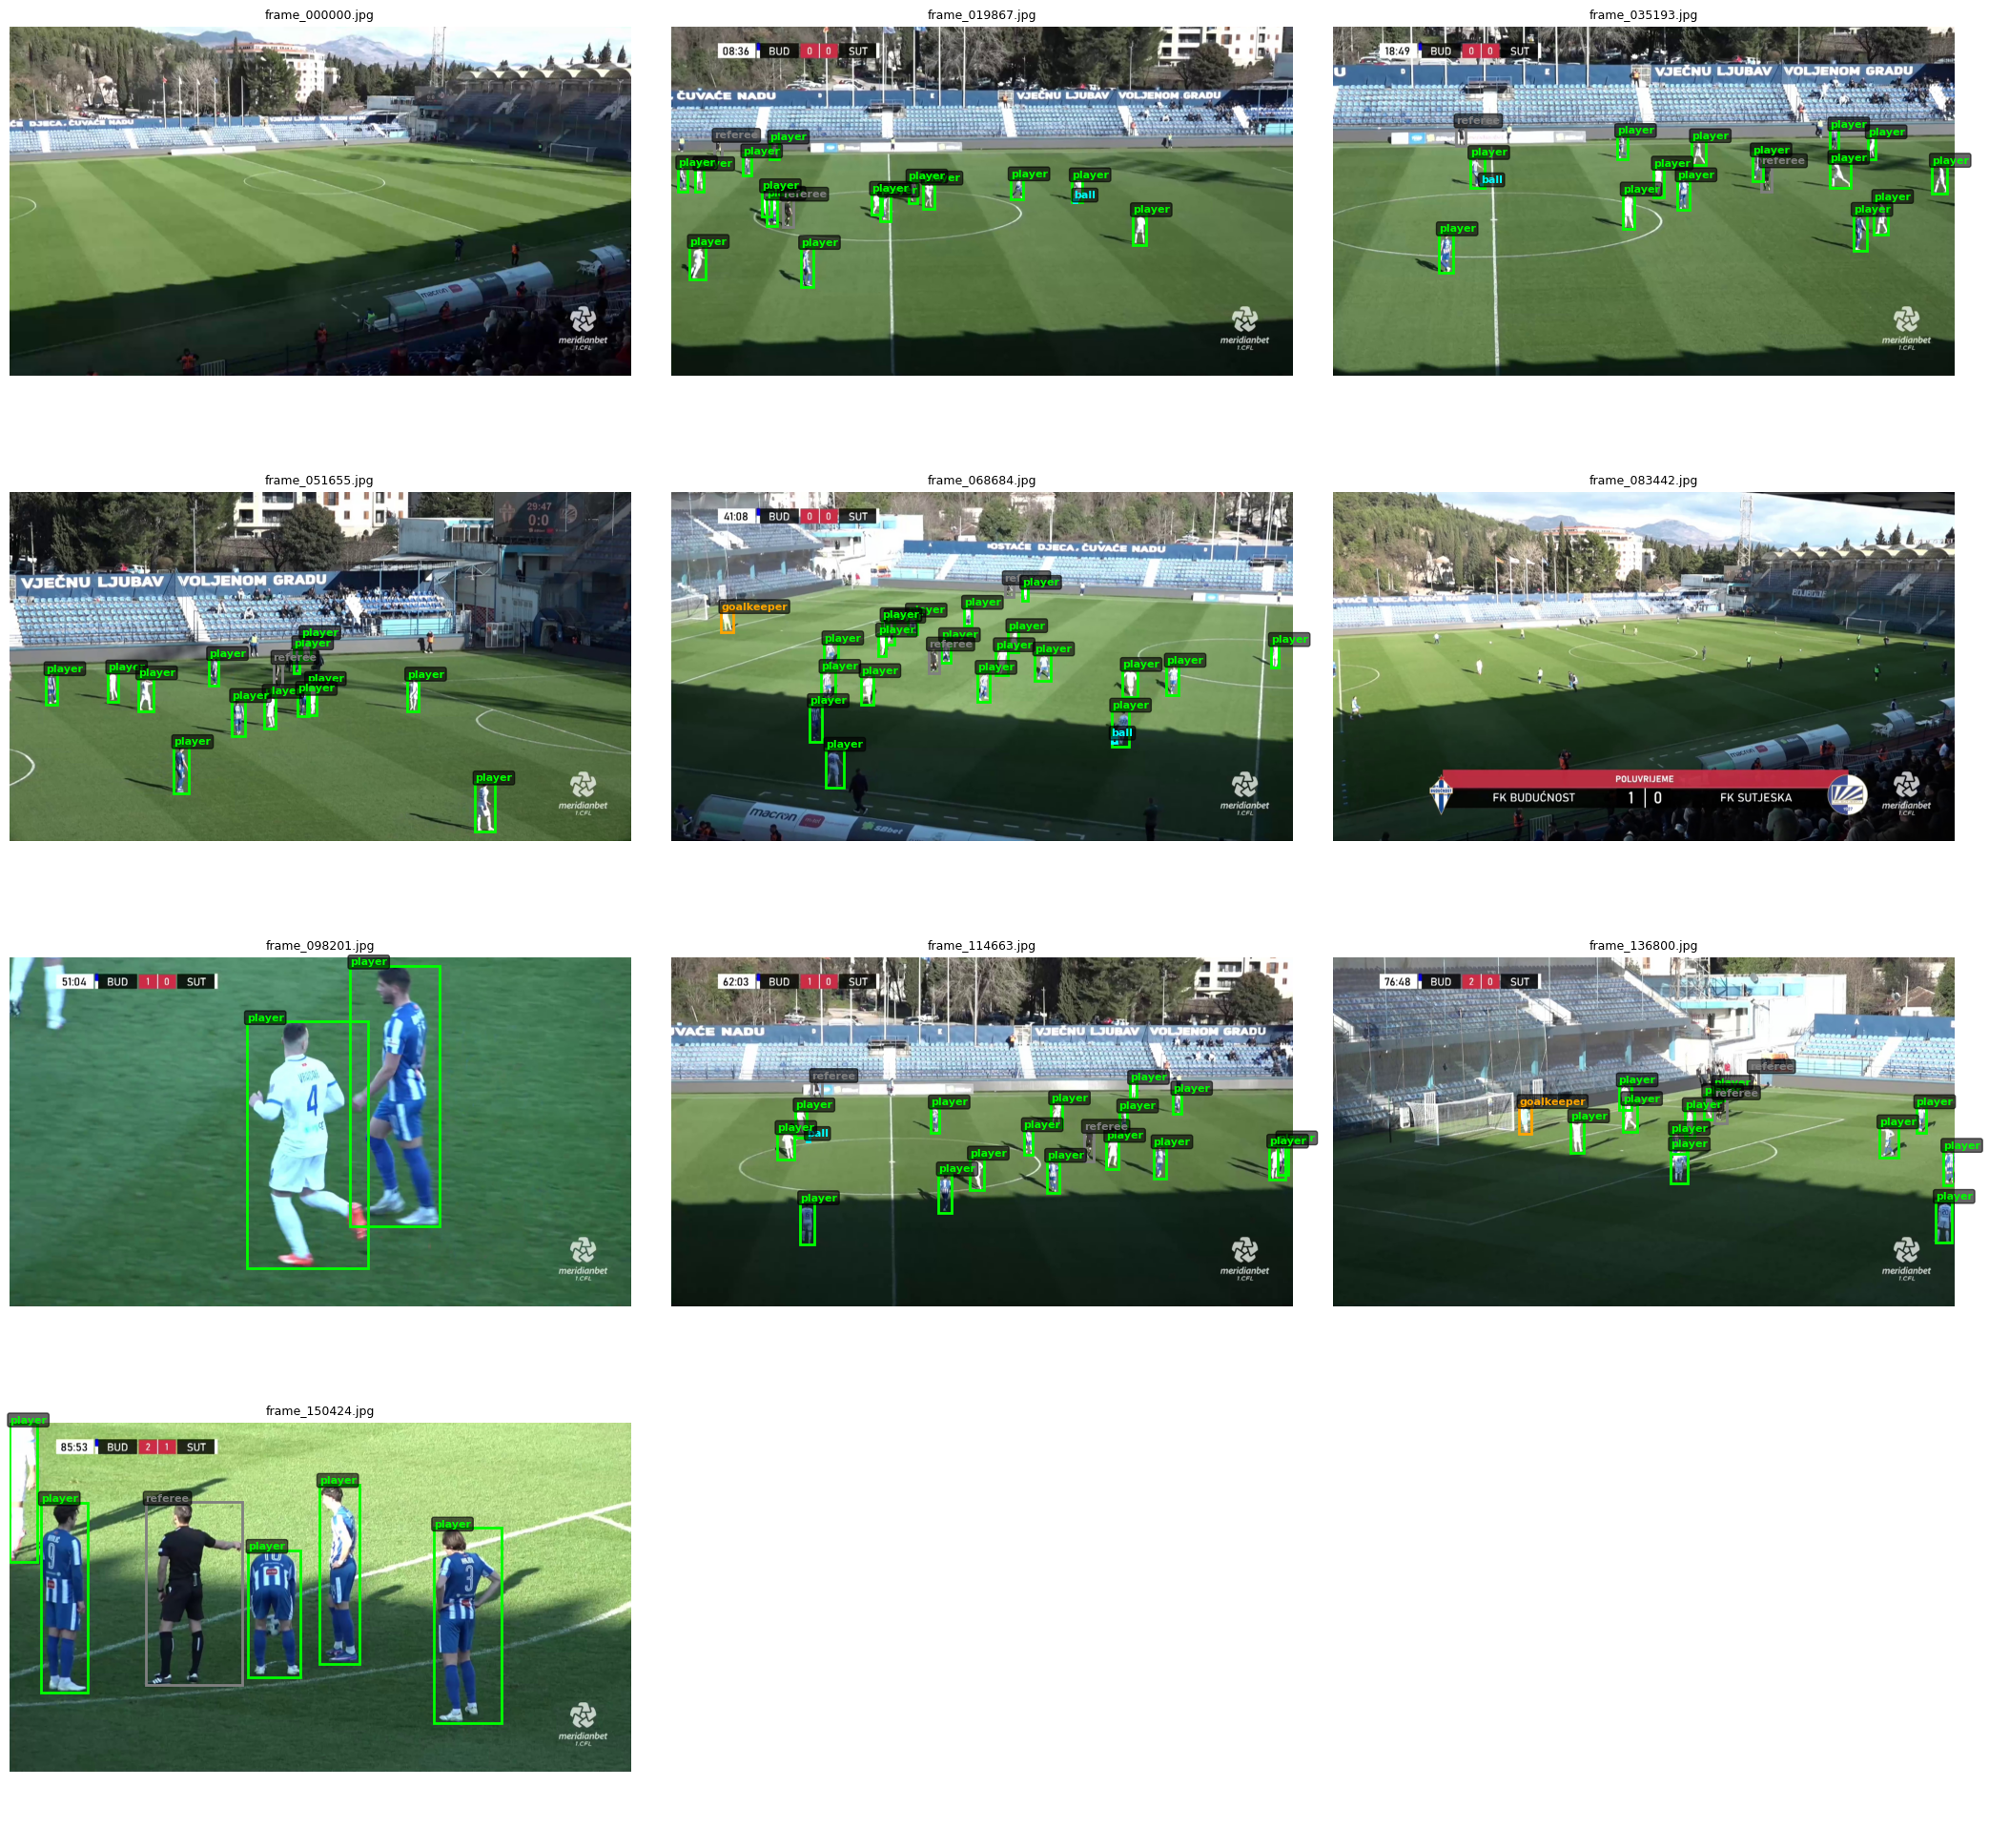

<Figure size 640x480 with 0 Axes>

In [2]:
# Verify the remap looks correct
visualize_labels(dataset_dir, n_samples=10)

In [5]:
# Split (safe to re-run — merges back first) and train
create_data_yaml(dataset_dir)
split_val(dataset_dir, val_ratio=0.2)

from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(
    data=str(dataset_dir / "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    name="football_finetune_v2",
    patience=10,
)

Created C:\Users\pavle\OneDrive\Desktop\my github\football-computer-vision\football-computer-vision\dataset\data.yaml
Split: 240 train, 60 val (from 300 total, 20% split)
New https://pypi.org/project/ultralytics/8.4.25 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.188  Python-3.13.2 torch-2.8.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\pavle\OneDrive\Desktop\my github\football-computer-vision\football-computer-vision\dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000024AE4FB7070>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       